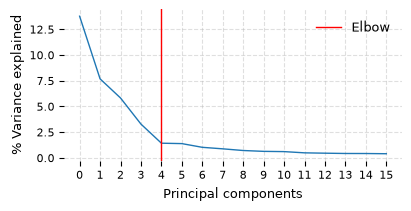

In [1]:
import matplotlib.pyplot as plt

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )
ds.run_normalization(feat_key="hvgs")
ds.run_pca(dims=15, show_elbow_plot=True)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_leiden_clustering(resolution=0.5)

In [2]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    label="UMAP",
)

In [3]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label="densMAP",
)

In [4]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    verbose=False,
)

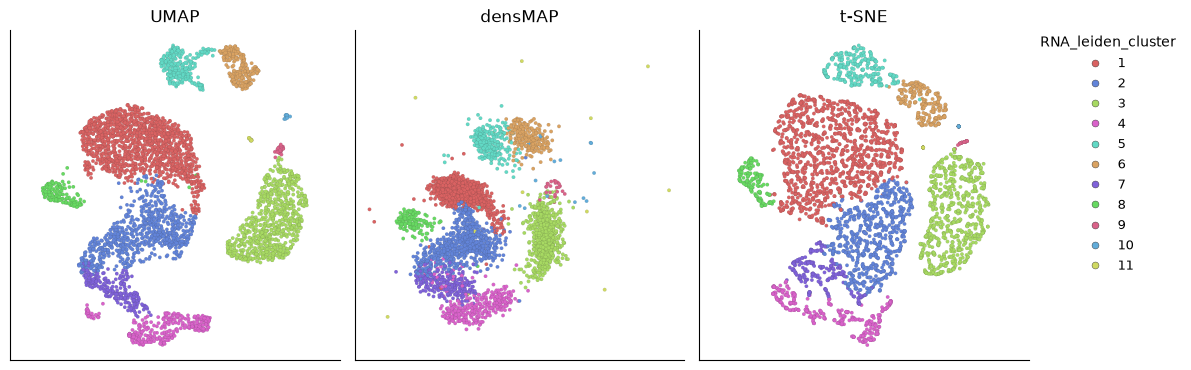

In [5]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
layout_comparisons = (
    ("UMAP", "RNA_UMAP"),
    ("densMAP", "RNA_densMAP"),
    ("t-SNE", "RNA_tSNE"),
)
for index, (axis, (title, layout_key)) in enumerate(
    zip(axes, layout_comparisons, strict=True)
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by="RNA_leiden_cluster",
        legend_loc="right",
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure